In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pickle
import os



In [28]:
# 1. Load Data
df = pd.read_csv(r'C:\Users\DELL\Desktop\svc\data\raw\Social_Network_Ads.csv')



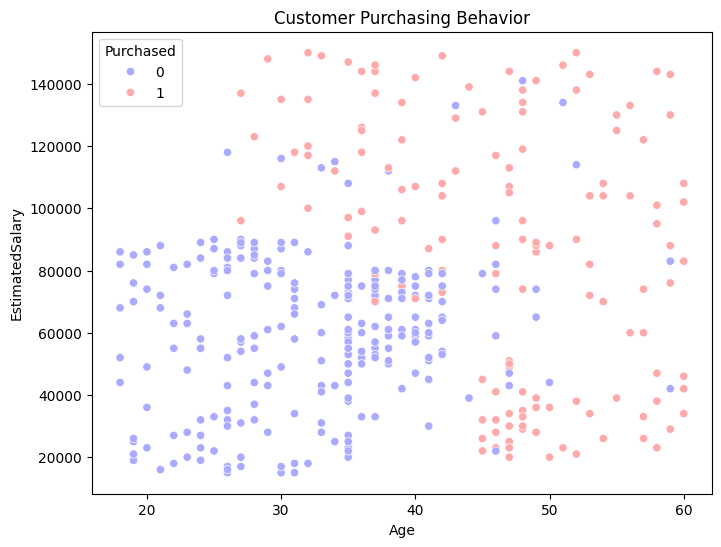

In [29]:
# 2. Quick EDA
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df, palette='bwr')
plt.title("Customer Purchasing Behavior")
plt.show()



In [30]:
# 3. Feature Selection
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']



In [31]:
# 4. Train/Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [32]:
# 5. Model Training (Support Vector Classifier with RBF Kernel)
# RBF is great here because the decision boundary is usually non-linear (an arc)
classifier = SVC(kernel='rbf', random_state=42, probability=True)
classifier.fit(X_train_scaled, y_train)



,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
# 6. Evaluation
y_pred = classifier.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))



Model Accuracy: 93.00%

              precision    recall  f1-score   support

           0       0.98      0.90      0.94        63
           1       0.86      0.97      0.91        37

    accuracy                           0.93       100
   macro avg       0.92      0.94      0.93       100
weighted avg       0.94      0.93      0.93       100



In [34]:
# 7. Export Artifacts
os.makedirs('models', exist_ok=True)
with open(r'C:\Users\DELL\Desktop\svc\models\svc_model.pkl', 'wb') as f:
    pickle.dump(classifier, f)
with open(r'C:\Users\DELL\Desktop\svc\models\svc_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)